In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# PCA on Yale Face Database

Centered Yale Face Dataset and its description are availiable at: https://vismod.media.mit.edu/vismod/classes/mas622-00/datasets/


# Give colab access to google drive

In [ ]:
from matplotlib import pyplot as plt
import numpy as np
from os import listdir
import os
import random
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


# Define SNR and MSE for Evaluation

In [ ]:
def snr_dB(actu,pred):
    err = pred.astype(np.float32) - actu.astype(np.float32)
    err = (err - np.mean(err, axis=(0,1)))
    sigma_n = np.var(err)
    actu = (actu - np.mean(actu, axis=(0,1)))
    sigma_s = np.var(actu.astype(np.float32))
    ns = sigma_s/sigma_n
    snr = np.mean(10 * np.log10(ns))
    return snr

def MSE(actu, pred):
     return np.square(actu - pred).mean()

# Show Some Training Images.

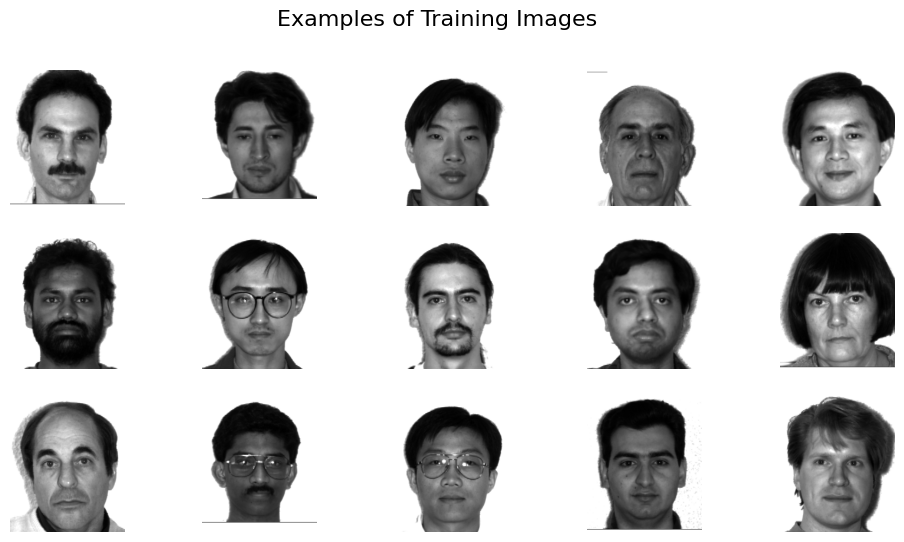

In [ ]:
work_path = "/content/drive/MyDrive/DigitalImageProcessing/"
filenames = os.listdir(work_path+ 'Data/centered')

train_idx = []
test_idx = []
for i in range(len(filenames)):
    if "centerlight" in filenames[i]:
        train_idx.append(i)
    else:
        test_idx.append(i)

random.seed(0)
test_idx = random.sample(test_idx, 6)

fig, ax = plt.subplots(3, 5, figsize=(12, 6))
fig.suptitle("Examples of Training Images", fontsize=16)
for i in range(3):
    for j in range(5):

        ax[i,j].imshow(plt.imread(work_path + 'Data/centered/' + filenames[train_idx[i*5+j]]), cmap='gray')
        ax[i,j].axis('off')
plt.show()


# Perform PCA display eigenfaces

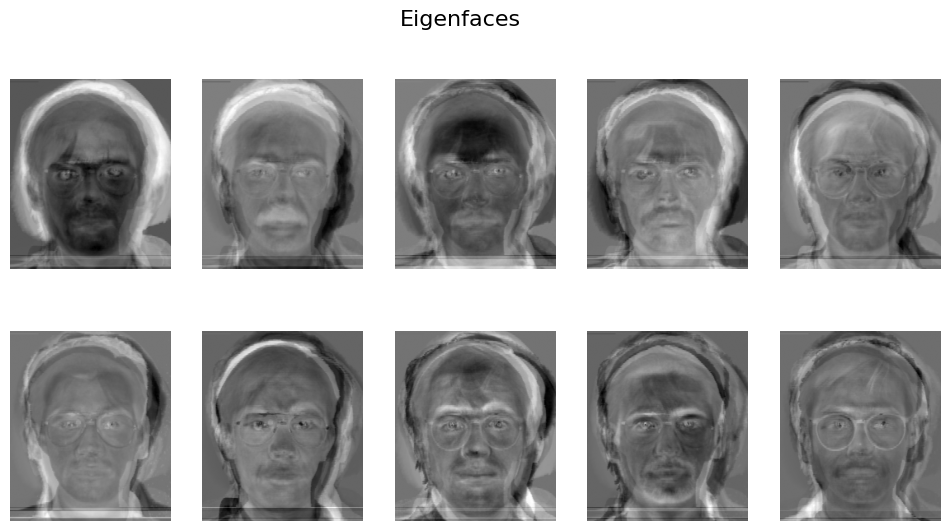

In [ ]:
from sklearn.decomposition import PCA

train_img = []
for i in train_idx:
      train_img.append(plt.imread(work_path + 'Data/centered/' + filenames[i]))

train_img = np.array(train_img)
train_img = np.reshape(train_img, (train_img.shape[0], -1))

pca = PCA(n_components=10).fit(train_img)

eigenfaces = pca.components_

fig, ax = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle("Eigenfaces", fontsize=16)
for i in range(2):
    for j in range(5):
        ax[i,j].imshow(np.reshape(eigenfaces[i*5+j],(231, 195)), cmap='gray')
        ax[i,j].axis('off')

plt.show()


# Reconstruct Training Images

Average SNR: 15.11 dB


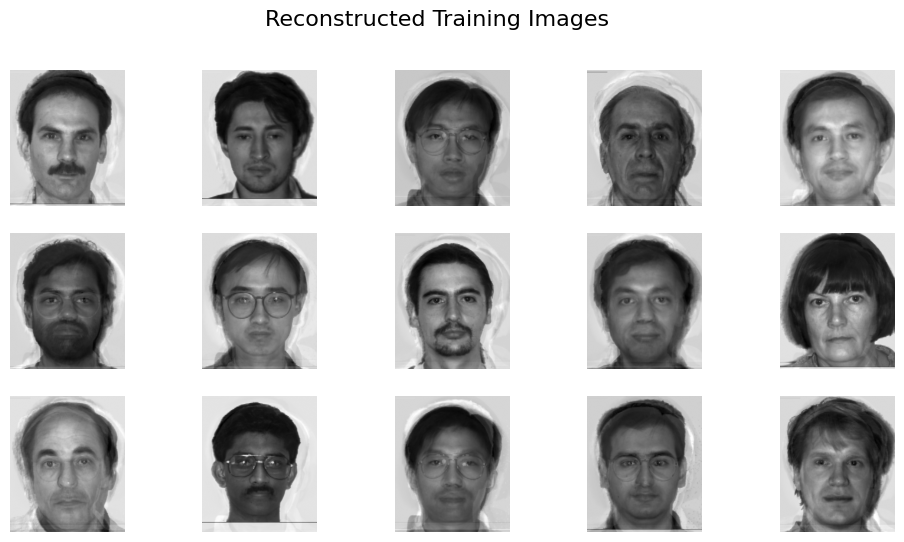

In [ ]:
train_pca = pca.transform(train_img)
train_rec = pca.inverse_transform(train_pca)

print('Average SNR: {:0.2f} dB'.format(snr_dB(train_img,train_rec)))

fig, ax = plt.subplots(3, 5, figsize=(12, 6))
fig.suptitle("Reconstructed Training Images", fontsize=16)
for i in range(3):
    for j in range(5):
        ax[i,j].imshow(np.reshape(train_rec[i*5+j],(231, 195)), cmap='gray')
        ax[i,j].axis('off')

plt.show()

# Test on 4 dinstinct images

subject10.wink.pgm
subject11.surprised.pgm
subject02.happy.pgm
subject07.surprised.pgm
subject14.glasses.pgm
subject13.sleepy.pgm
Average SNR: 6.66 dB


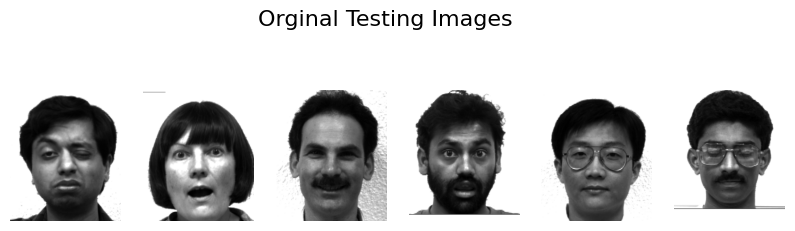

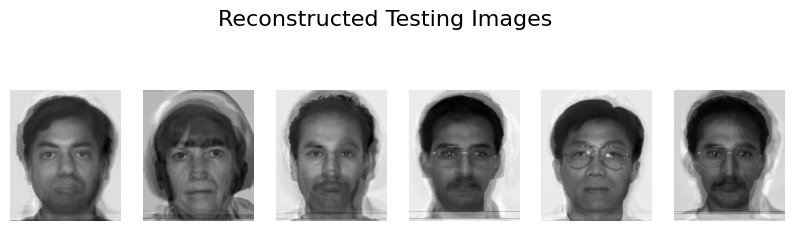

In [ ]:
pca = PCA(n_components=14).fit(train_img)

test_img = []
for i in test_idx:
      print(filenames[i])
      test_img.append(plt.imread(work_path + 'Data/centered/' + filenames[i]))

test_img = np.array(test_img)
test_img = np.reshape(test_img, (test_img.shape[0], -1))

test_pca = pca.transform(test_img)
test_rec = pca.inverse_transform(test_pca)

print('Average SNR: {:0.2f} dB'.format(snr_dB(test_img,test_rec)))

fig, ax = plt.subplots(1, 6, figsize=(10, 3))
fig.suptitle("Orginal Testing Images", fontsize=16)
for i in range(6):
    ax[i].imshow(np.reshape(test_img[i],(231, 195)), cmap='gray')
    ax[i].axis('off')


fig, ax = plt.subplots(1, 6, figsize=(10, 3))
fig.suptitle("Reconstructed Testing Images", fontsize=16)
for i in range(6):
    ax[i].imshow(np.reshape(test_rec[i],(231, 195)), cmap='gray')
    ax[i].axis('off')

plt.show()

# Extend to whole dataset

Find eigenfaces using 12 PCs

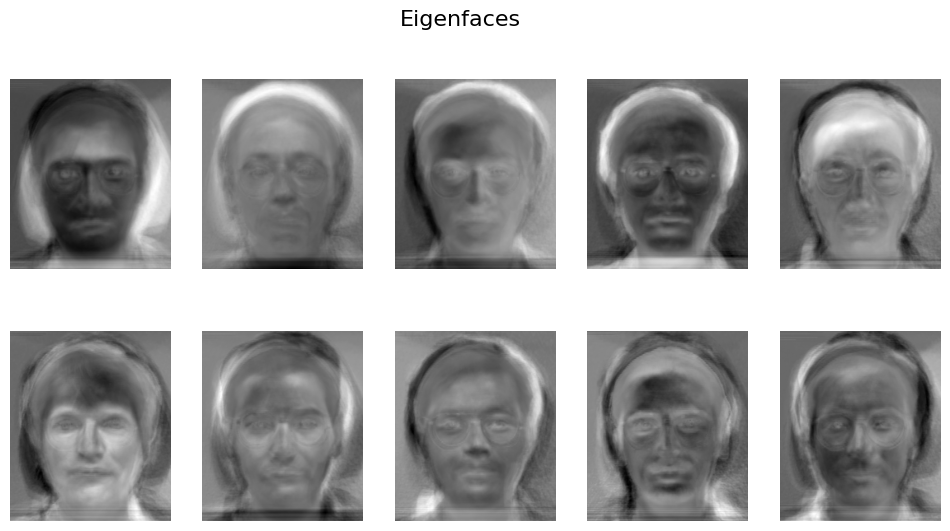

In [ ]:
train_idx = random.sample(range(len(filenames)),int(len(filenames)*0.7))
test_idx = [i for i in range(len(filenames)) if i not in train_idx]

from sklearn.decomposition import PCA

train_img = []
for i in train_idx:
      train_img.append(plt.imread(work_path + 'Data/centered/' + filenames[i]))

train_img = np.array(train_img)
train_img = np.reshape(train_img, (train_img.shape[0], -1))

pca = PCA(n_components=12).fit(train_img)

eigenfaces = pca.components_[:10]

fig, ax = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle("Eigenfaces", fontsize=16)
for i in range(2):
    for j in range(5):
        ax[i,j].imshow(np.reshape(eigenfaces[i*5+j],(231, 195)), cmap='gray')
        ax[i,j].axis('off')
plt.show()


Perform PCA and reconstruction on training images

Average SNR: 9.89 dB


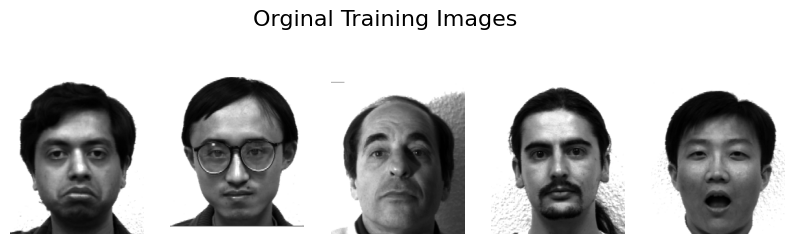

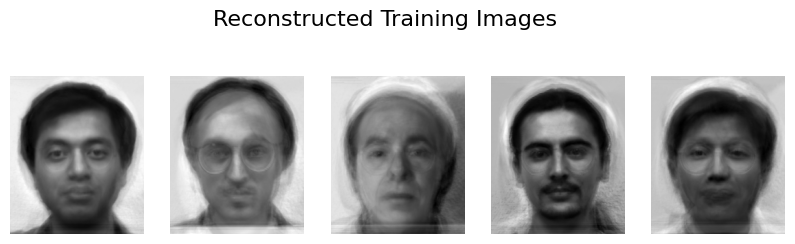

In [ ]:
train_pca = pca.transform(train_img)
train_rec = pca.inverse_transform(train_pca)

print('Average SNR: {:0.2f} dB'.format(snr_dB(train_img,train_rec)))

fig, ax = plt.subplots(1, 5, figsize=(10, 3))
fig.suptitle("Orginal Training Images", fontsize=16)
for i in range(5):
    ax[i].imshow(np.reshape(train_img[i],(231, 195)), cmap='gray')
    ax[i].axis('off')

fig, ax = plt.subplots(1, 5, figsize=(10, 3))
fig.suptitle("Reconstructed Training Images", fontsize=16)
for i in range(5):
    ax[i].imshow(np.reshape(train_rec[i],(231, 195)), cmap='gray')
    ax[i].axis('off')
plt.show()


# Perform PCA and reconstruction on testing images

Average SNR: 8.76 dB


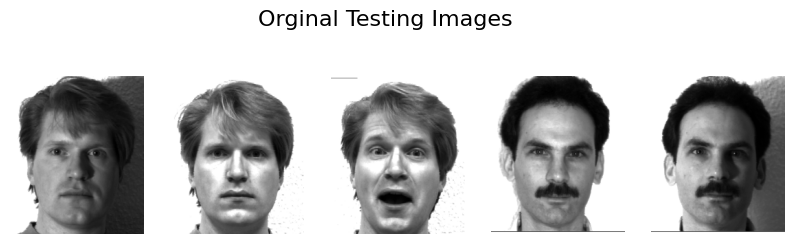

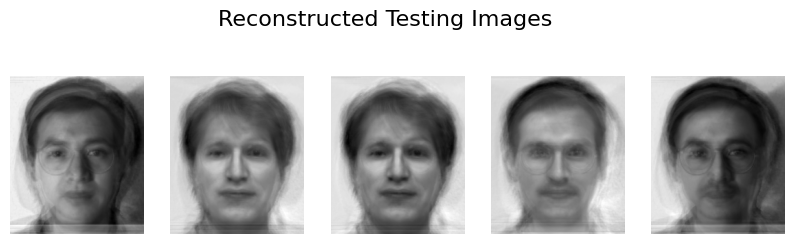

In [ ]:
test_img = []
for i in test_idx:
      test_img.append(plt.imread(work_path + 'Data/centered/' + filenames[i]))

test_img = np.array(test_img)
test_img = np.reshape(test_img, (test_img.shape[0], -1))

test_pca = pca.transform(test_img)
test_rec = pca.inverse_transform(test_pca)

print('Average SNR: {:0.2f} dB'.format(snr_dB(test_img,test_rec)))

fig, ax = plt.subplots(1, 5, figsize=(10, 3))
fig.suptitle("Orginal Testing Images", fontsize=16)
for i in range(5):
    ax[i].imshow(np.reshape(test_img[i],(231, 195)), cmap='gray')
    ax[i].axis('off')

fig, ax = plt.subplots(1, 5, figsize=(10, 3))
fig.suptitle("Reconstructed Testing Images", fontsize=16)
for i in range(5):
    ax[i].imshow(np.reshape(test_rec[i],(231, 195)), cmap='gray')
    ax[i].axis('off')
plt.show()